In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
import os
import glob
from datetime import timedelta

# Asymmetric Tidal Resuspension ?

In [2]:
jjii = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

a, b = finder(49.2, -123.5)


In [ ]:

# --- 2. Define Time Period ---
# 14-day window to capture a full spring-neap tidal cycle
begin = pd.to_datetime('2007-08-15') 
end = pd.to_datetime('2007-10-15')
t_len = (end - begin).days

def date_files(date, path, prefix_type='grid_T.nc'):
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path, folder + f'/SalishSea_1h_{date.strftime("%Y%m%d").lower()}_{date.strftime("%Y%m%d").lower()}_{prefix_type}*')
    file_name = glob.glob(prefix) 
    return file_name

def get_timestamps(start, length):
    timestamps=[]
    duration = timedelta(days=length)
    for day in range(duration.days):
        timestamps.append([start + timedelta(days=day)])
    return timestamps

dates = get_timestamps(begin, t_len)

# --- 3. Dynamically Find the Bottom Depth Index ---
path_bat = '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc'
bat_file = xr.open_dataset(path_bat)
mbathy = bat_file['mbathy'][0]
# In NEMO, mbathy gives the number of w-levels. The bottom T/U/V cell index is mbathy - 1
depth_idx = int(mbathy.isel(y=a, x=b).values) - 1 

# --- 4. File Paths Loop ---
path_days_h = '/results2/SalishSea/nowcast-green.202111/'
files_U, files_V, files_e3t = [], [], []

for i in range(t_len):
    files_U.append(date_files(dates[i][0], path_days_h, prefix_type='grid_U.nc'))
    files_V.append(date_files(dates[i][0], path_days_h, prefix_type='grid_V.nc'))
    files_e3t.append(date_files(dates[i][0], path_days_h, prefix_type='grid_T.nc'))

filepaths_U = [f[0] for f in files_U]
filepaths_V = [f[0] for f in files_V]
filepaths_e3t = [f[0] for f in files_e3t]

# --- 5. Data Extraction ---
print(f"Extracting data at y={a}, x={b}, depth index={depth_idx}...")
U_vels, V_vels, e3ts, sshs = [], [], [], []

for file_u, file_v, file_e in zip(filepaths_U, filepaths_V, filepaths_e3t):
    datito_u = xr.open_dataset(file_u)['vozocrtx'].isel(depthu=depth_idx, y=a, x=b)
    datito_v = xr.open_dataset(file_v)['vomecrty'].isel(depthv=depth_idx, y=a, x=b)
    datito_e3t = xr.open_dataset(file_e)['e3t'].isel(deptht=depth_idx, y=a, x=b)
    datito_ssh = xr.open_dataset(file_e)['sossheig'].isel(y=a, x=b) # Extracting SSH from grid_T
    
    U_vels.append(datito_u)
    V_vels.append(datito_v)
    e3ts.append(datito_e3t)
    sshs.append(datito_ssh)

U_velocity = xr.concat(U_vels, dim='time_counter')
V_velocity = xr.concat(V_vels, dim='time_counter')
e3t_values = xr.concat(e3ts, dim='time_counter')
ssh_values = xr.concat(sshs, dim='time_counter')

# --- 6. Physics Calculations ---
z = e3t_values / 2
z_star = 0.07
k = 0.42
rho = 1024 # kg/m3

vel_horizontal = np.sqrt(U_velocity**2 + V_velocity**2)

with np.errstate(divide='ignore', invalid='ignore'):
    u_star = (vel_horizontal * k) / np.log(z / z_star)

tau = rho * (u_star ** 2)

Extracting data at y=460, x=276, depth index=35...


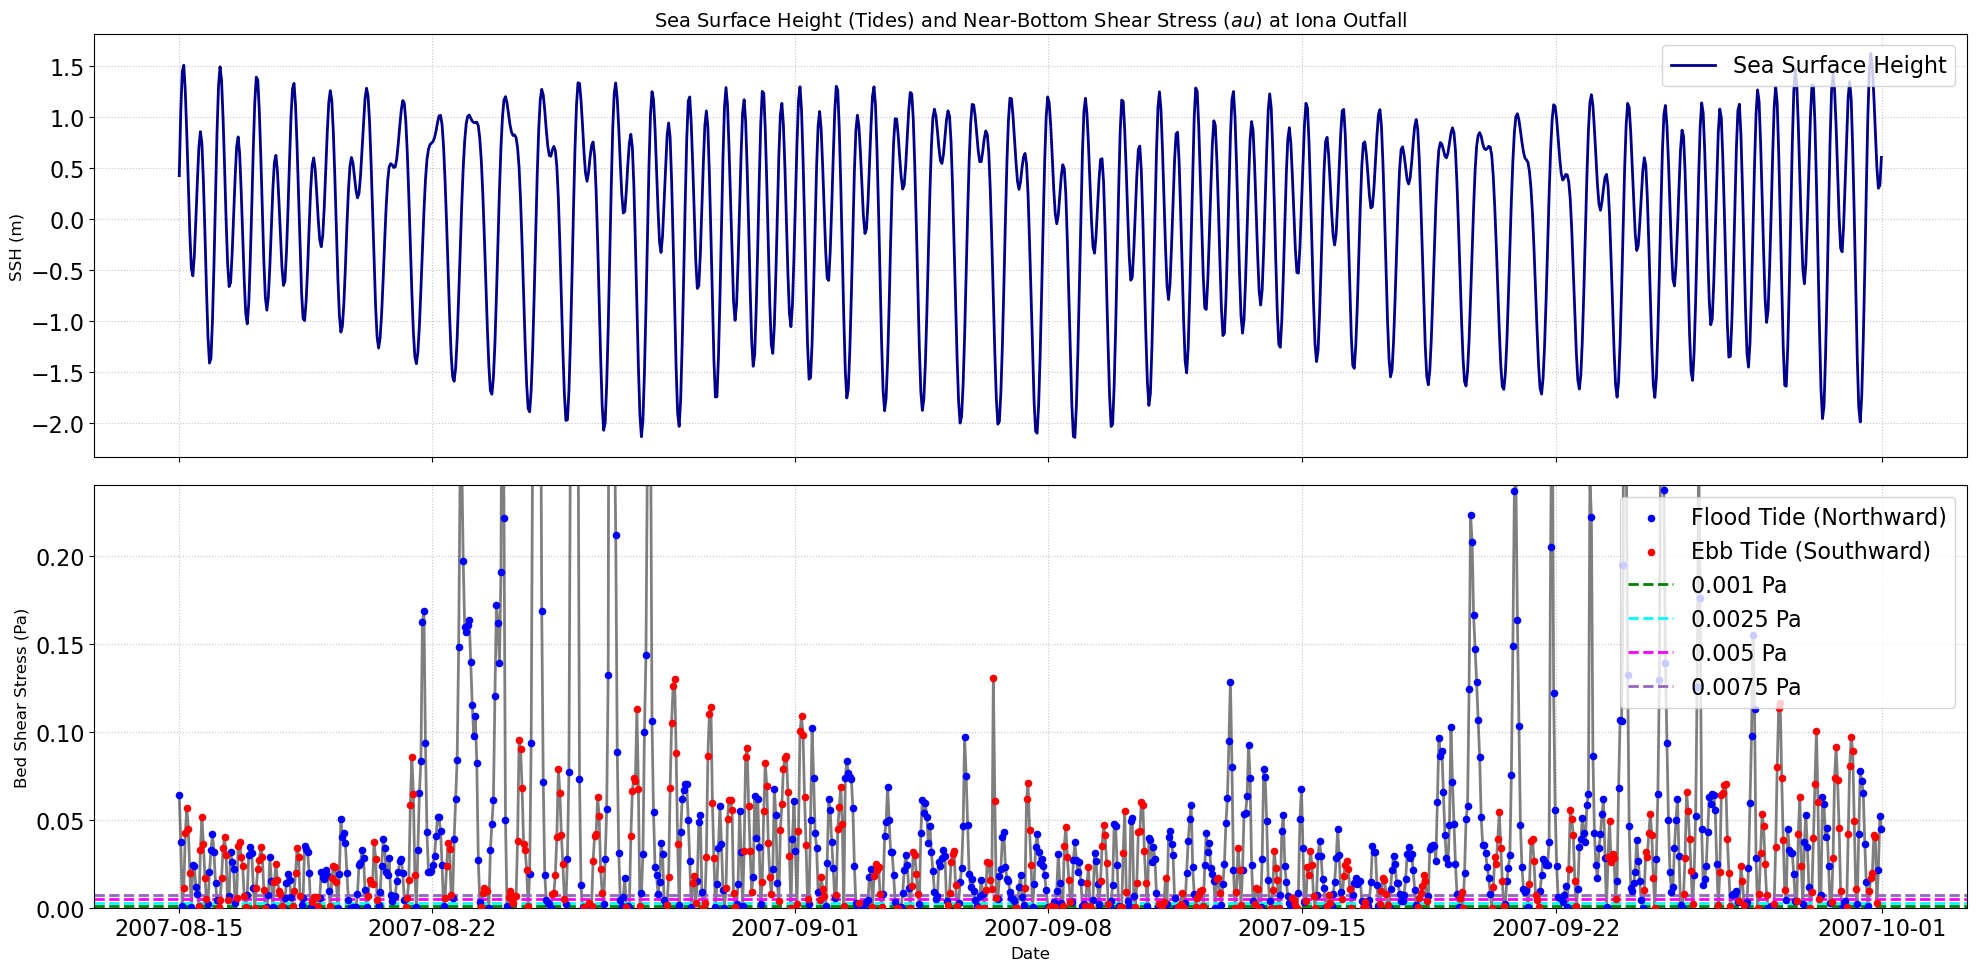

In [4]:
plt.rcParams.update({'font.size': 16})
fig, (ax_ssh, ax_tau) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

times = tau.time_counter.values
tau_vals = tau.values
v_vals = V_velocity.values # V velocity for North (Flood) vs South (Ebb)
ssh_vals = ssh_values.values 

ax_ssh.plot(times, ssh_vals, color='darkblue', linewidth=2, label='Sea Surface Height')
ax_ssh.set_title('Sea Surface Height (Tides) and Near-Bottom Shear Stress ($\tau$) at Iona Outfall', fontsize=14)
ax_ssh.set_ylabel('SSH (m)', fontsize=12)
ax_ssh.grid(True, linestyle=':', alpha=0.7)
ax_ssh.legend(loc='upper right')

ax_tau.plot(times, tau_vals, color='black', alpha=0.5, linewidth=2)

# Positive V is generally Flood (Northward) in the Strait
ax_tau.scatter(times[v_vals > 0], tau_vals[v_vals > 0], color='blue', s=20, zorder=3, label='Flood Tide (Northward)')
# Negative V is generally Ebb (Southward)
ax_tau.scatter(times[v_vals <= 0], tau_vals[v_vals <= 0], color='red', s=20, zorder=3, label='Ebb Tide (Southward)')

# Add critical thresholds from the V-shape plot
ax_tau.axhline(y=0.001, color='green', linestyle='--', linewidth=2, label='0.001 Pa')
ax_tau.axhline(y=0.0025, color='cyan', linestyle='--', linewidth=2, label='0.0025 Pa')
ax_tau.axhline(y=0.005, color='magenta', linestyle='--', linewidth=2, label='0.005 Pa')
ax_tau.axhline(y=0.0075, color='tab:purple', linestyle='--', linewidth=2, label='0.0075 Pa')

ax_tau.set_ylabel('Bed Shear Stress (Pa)', fontsize=12)
ax_tau.set_xlabel('Date', fontsize=12)

# Set y-limit dynamically, ensuring the 0.005 line is always visible
y_max = max(np.nanpercentile(tau_vals, 99) * 1.2, 0.006)
ax_tau.set_ylim(0,0.24) 

ax_tau.grid(True, linestyle=':', alpha=0.7)
ax_tau.legend(loc='upper right')
#

plt.tight_layout()
plt.show()

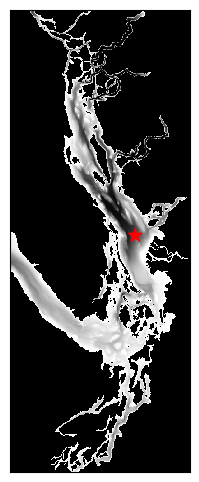

In [5]:
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
from matplotlib.colors import ListedColormap
colors = [(0, 0, 0, 1),  # Black for land (1)
            (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)
fig, ax = plt.subplots(figsize = (4,6))
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap)
ax.pcolormesh(bathy['Bathymetry'], cmap = 'Greys')
ax.scatter(b,a, s = 100, marker = '*', color = 'r')
ax.tick_params(which='both',bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
ax.set_aspect(1.14)

The modeling results demonstrate a counter-intuitive expansion of the spatial dispersion footprint at higher critical bed shear stresses ($\tau_{crit}$). At a low threshold ($\tau_{crit} = 0.001$ Pa), particles remain in a state of near-continuous suspension, leading to symmetrical tidal advection that functions effectively as localized diffusion, thereby retaining mass near the outfall. Conversely, at an elevated threshold ($\tau_{crit} = 0.0075$ Pa), transport becomes highly episodic. Under these conditions, particles are subjected to severe scour and settling lag effects driven by the tidal asymmetry of the Strait of Georgia. Because transport scales non-linearly with excess shear stress, resuspension occurs exclusively during the maximum velocity phases of the dominant tidal vector. This activates a "tidal pumping" mechanism that shifts the transport regime from local diffusion to advection-dominated directional export, ultimately generating the massively expanded, asymmetric distribution footprint observed in the simulation.

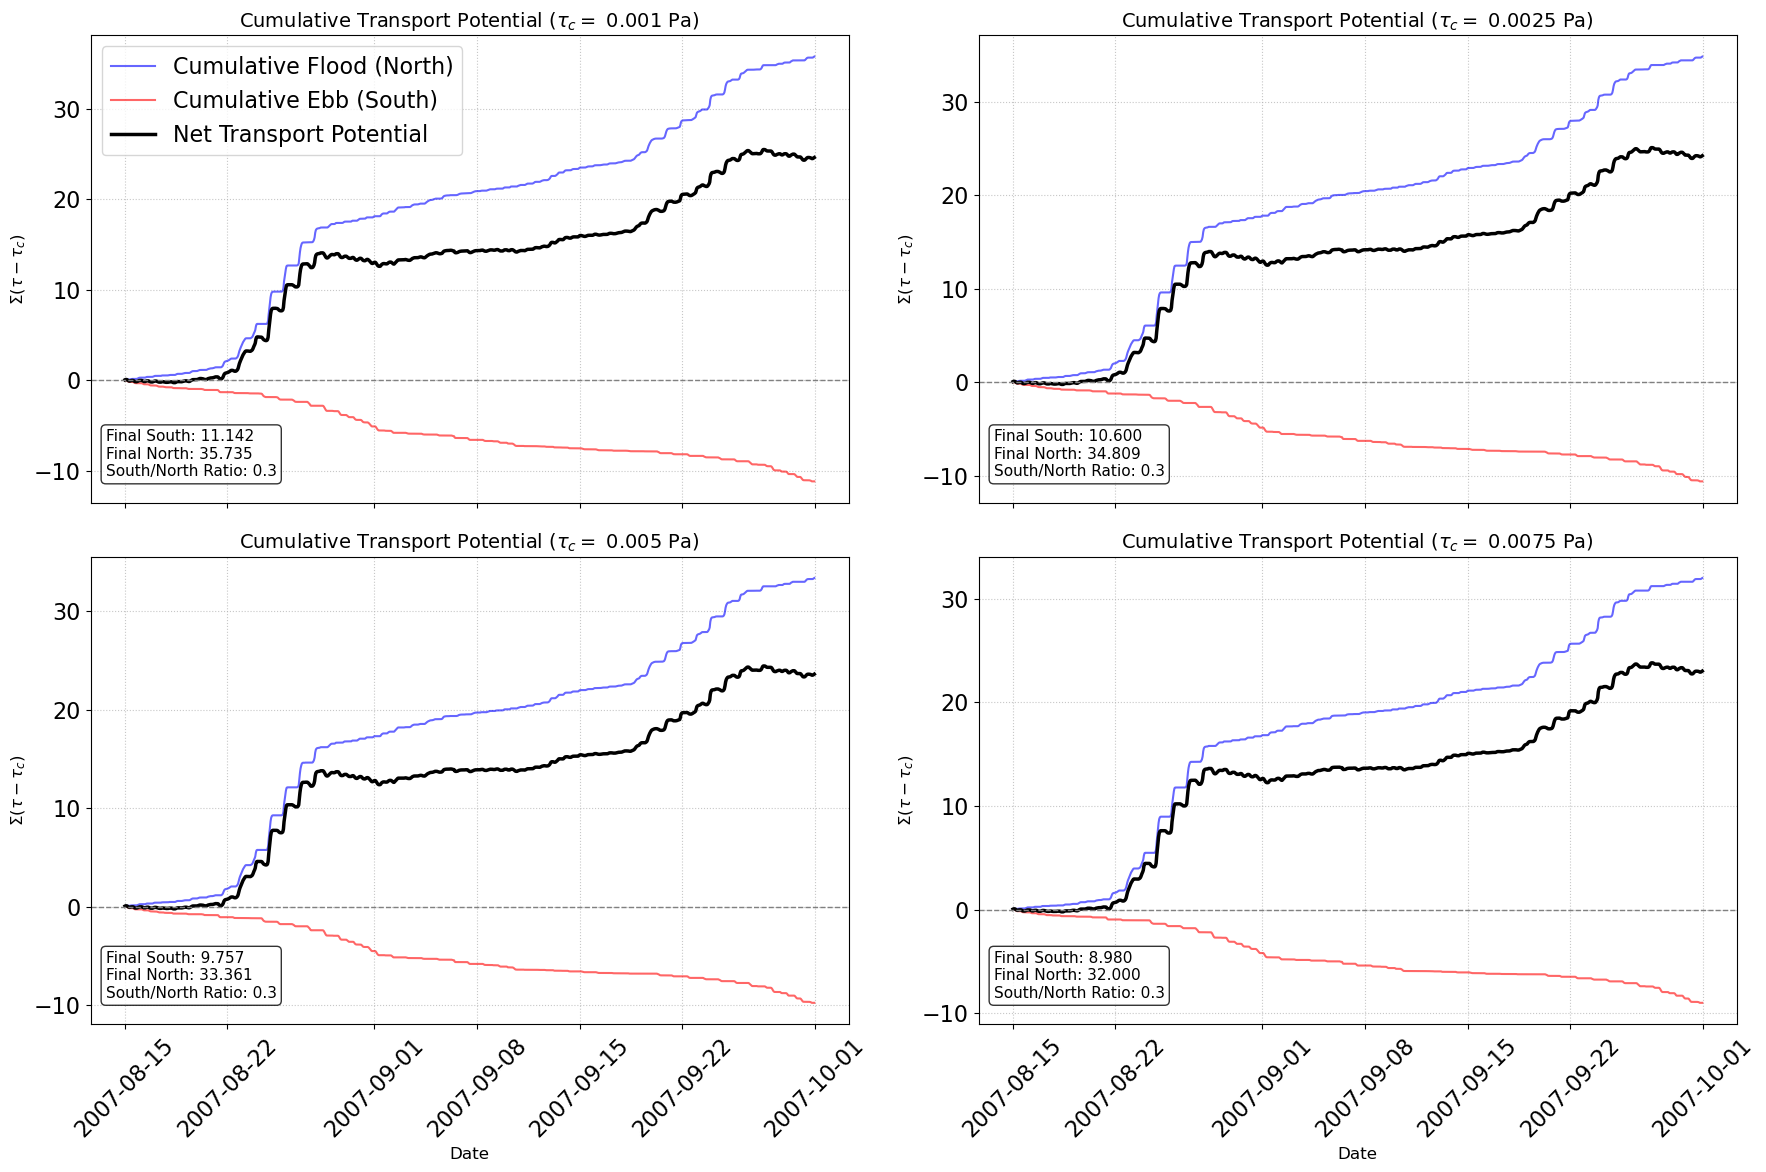

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define your thresholds
thresholds = [0.001, 0.0025, 0.005, 0.0075]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for i, tc in enumerate(thresholds):
    ax = axes[i]
    
    # 1. Calculate Excess Shear Stress (tau - tau_crit)
    # Set to 0 if tau is below the threshold
    excess_tau = np.maximum(tau_vals - tc, 0)
    
    # 2. Separate into Flood (North/Positive) and Ebb (South/Negative)
    # Note: We make Ebb negative so it plots downward, showing a tug-of-war
    flood_excess = np.where(v_vals > 0, excess_tau, 0)
    ebb_excess = np.where(v_vals <= 0, -excess_tau, 0) 
    
    # 3. Calculate Cumulative Sums
    cum_flood = np.cumsum(flood_excess)
    cum_ebb = np.cumsum(ebb_excess)
    net_transport = cum_flood + cum_ebb # The overall direction
    
    # 4. Plotting
    ax.plot(times, cum_flood, color='blue', alpha=0.6, label='Cumulative Flood (North)')
    ax.plot(times, cum_ebb, color='red', alpha=0.6, label='Cumulative Ebb (South)')
    ax.plot(times, net_transport, color='black', linewidth=2.5, label='Net Transport Potential')
    
    # Formatting
    ax.set_title(rf'Cumulative Transport Potential ($\tau_c =$ {tc} Pa)', fontsize=14)
    ax.set_ylabel(rf'$\Sigma (\tau - \tau_c)$', fontsize=12)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Add a text box to explicitly quantify the final ratio
    final_flood = cum_flood[-1]
    final_ebb = abs(cum_ebb[-1])
    
    # Avoid division by zero
    ratio = final_ebb / final_flood if final_flood > 0 else np.nan
    
    text_str = f"Final South: {final_ebb:.3f}\nFinal North: {final_flood:.3f}\nSouth/North Ratio: {ratio:.1f}"
    ax.text(0.02, 0.05, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    if i == 0:
        ax.legend(loc='upper left')

for ax in axes[2:]:
    ax.set_xlabel('Date', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Spatial

Extracting 2D bottom layer across all time steps...
Calculating Shear Stress...
Aggregating time series into spatial maps...


/tmp/ipykernel_97263/2191386589.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('magma_r', len(bounds) - 1)


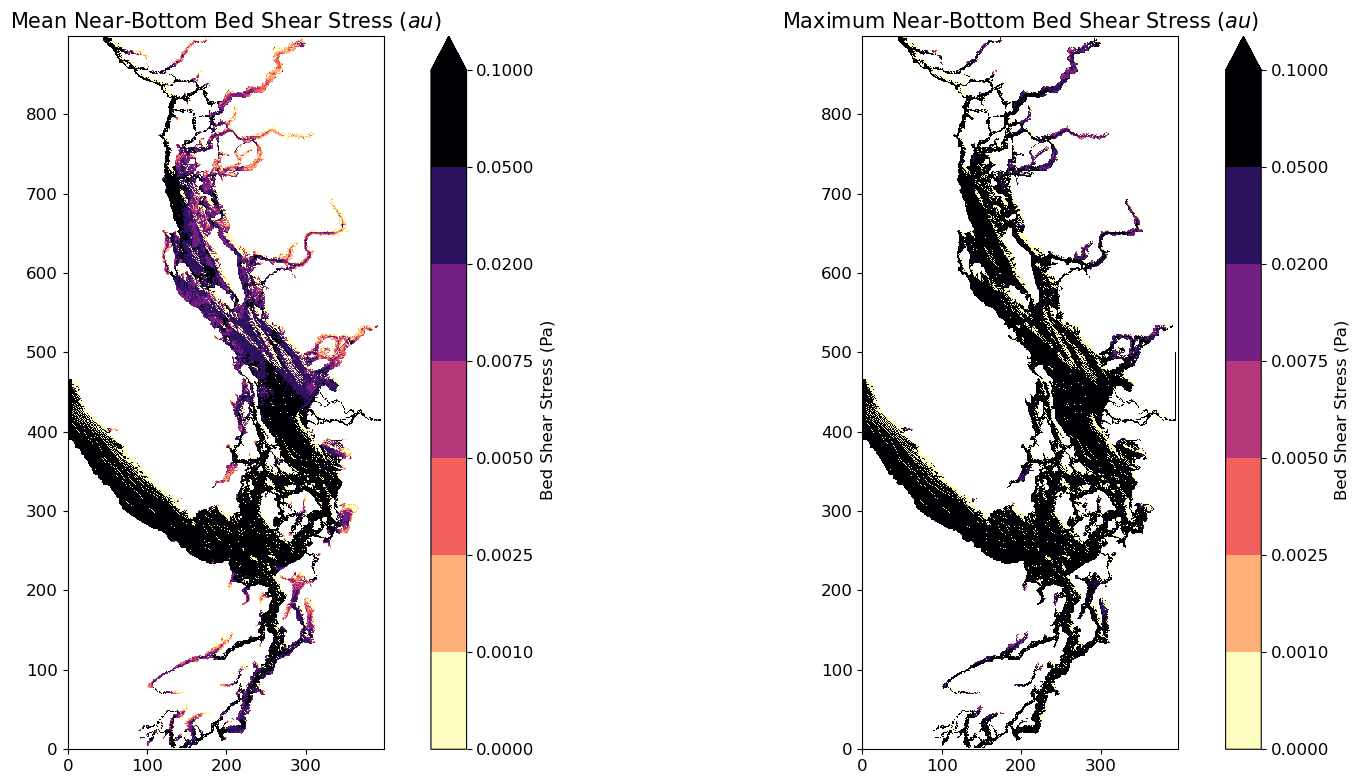

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import glob
from datetime import timedelta

# --- 1. Define Time Period ---
begin = pd.to_datetime('2007-08-15') 
end = pd.to_datetime('2007-10-15')
t_len = (end - begin).days

def date_files(date, path, prefix_type='grid_T.nc'):
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path, folder + f'/SalishSea_1h_{date.strftime("%Y%m%d").lower()}_{date.strftime("%Y%m%d").lower()}_{prefix_type}*')
    return glob.glob(prefix)

def get_timestamps(start, length):
    return [start + timedelta(days=day) for day in range(length)]

dates = get_timestamps(begin, t_len)

# --- 2. Dynamically Find the 2D Bottom Depth Index ---
path_bat = '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc'
bat_file = xr.open_dataset(path_bat)
mbathy = bat_file['mbathy'][0]
tmask = bat_file['tmask'][0, 0, :, :] # Surface mask to hide land later

# Create a 2D array of bottom indices (mbathy - 1)
# We replace -1 (land) with 0 to prevent Xarray indexing errors, then mask it later
depth_idx_2d = (mbathy - 1).where((mbathy - 1) >= 0, 0).astype(int)

# --- 3. File Paths Loop ---
path_days_h = '/results2/SalishSea/nowcast-green.202111/'
files_U, files_V, files_e3t = [], [], []

for i in range(t_len):
    files_U.extend(date_files(dates[i], path_days_h, prefix_type='grid_U.nc'))
    files_V.extend(date_files(dates[i], path_days_h, prefix_type='grid_V.nc'))
    files_e3t.extend(date_files(dates[i], path_days_h, prefix_type='grid_T.nc'))

# --- 4. Memory-Efficient Data Extraction ---
print("Extracting 2D bottom layer across all time steps...")
U_vels, V_vels, e3ts = [], [], []

# Using chunks allows Dask to handle the massive memory load of 2 months of domain data
for file_u, file_v, file_e in zip(files_U, files_V, files_e3t):
    ds_u = xr.open_dataset(file_u, chunks={'time_counter': 24})
    ds_v = xr.open_dataset(file_v, chunks={'time_counter': 24})
    ds_e = xr.open_dataset(file_e, chunks={'time_counter': 24})
    
    # Extract the bottom 2D slice using our 2D index array
    u_bot = ds_u['vozocrtx'].isel(depthu=depth_idx_2d)
    v_bot = ds_v['vomecrty'].isel(depthv=depth_idx_2d)
    e3t_bot = ds_e['e3t'].isel(deptht=depth_idx_2d)
    
    U_vels.append(u_bot)
    V_vels.append(v_bot)
    e3ts.append(e3t_bot)

U_velocity = xr.concat(U_vels, dim='time_counter')
V_velocity = xr.concat(V_vels, dim='time_counter')
e3t_values = xr.concat(e3ts, dim='time_counter')

# --- 5. Physics Calculations (Dask Lazy Evaluation) ---
print("Calculating Shear Stress...")
z = e3t_values / 2
z_star = 0.07
k = 0.42
rho = 1024 # kg/m3

vel_horizontal = np.sqrt(U_velocity**2 + V_velocity**2)

with np.errstate(divide='ignore', invalid='ignore'):
    u_star = (vel_horizontal * k) / np.log(z / z_star)

tau = rho * (u_star ** 2)

# Mask out the land (where tmask == 0)
tau = tau.where(tmask == 1)

# --- 6. Time Aggregation ---
print("Aggregating time series into spatial maps...")
# Calculate mean and maximum tau over the 2-month period. 
# .compute() triggers Dask to actually perform the math and bring the 2D map into memory.
tau_mean = tau.mean(dim='time_counter').compute()
tau_max = tau.max(dim='time_counter').compute()

# --- 7. Plotting the Spatial Maps ---
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Set up discrete color boundaries mapping to your experimental thresholds
bounds = [0, 0.001, 0.0025, 0.005, 0.0075, 0.02, 0.05, 0.1]
cmap = plt.cm.get_cmap('magma_r', len(bounds) - 1)
cmap.set_under('lightgray') # Color for land or zero values
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot Mean Bed Shear Stress
mesh1 = ax1.pcolormesh(tau_mean.values, cmap=cmap, norm=norm)
ax1.set_title('Mean Near-Bottom Bed Shear Stress ($\tau$)', fontsize=15)
ax1.set_aspect('equal') # Keeps the grid cells square
fig.colorbar(mesh1, ax=ax1, label='Bed Shear Stress (Pa)', extend='max')

# Plot Max Bed Shear Stress
mesh2 = ax2.pcolormesh(tau_max.values, cmap=cmap, norm=norm)
ax2.set_title('Maximum Near-Bottom Bed Shear Stress ($\tau$)', fontsize=15)
ax2.set_aspect('equal')
fig.colorbar(mesh2, ax=ax2, label='Bed Shear Stress (Pa)', extend='max')

# Optional: Zoom into the Iona outfall region (adjust these indices as needed)
# ax1.set_xlim(b - 100, b + 100)
# ax1.set_ylim(a - 100, a + 100)
# ax2.set_xlim(b - 100, b + 100)
# ax2.set_ylim(a - 100, a + 100)

plt.tight_layout()
plt.show()

In [18]:
tau_calculated = xr.open_dataset('/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/tau_AUG15-OCT15.nc')